# Setup

In [1]:
%%time
#%load_ext autoreload
#%autoreload 2

CPU times: total: 0 ns
Wall time: 6.91 μs


In [2]:
%%time
import os
import numpy as np
import matplotlib.pyplot as plt

CPU times: total: 969 ms
Wall time: 1.43 s


In [3]:
%%time
import sys

sys.path.append("../utils")

CPU times: total: 0 ns
Wall time: 47.9 μs


# Data

In [4]:
%%time
import data_2p_loader as data_loader


df_rois, df_fields, df_outline = data_loader.load_all_dfs()
df = data_loader.load_df_rois_morph(df_rois=df_rois)

CPU times: total: 7.38 s
Wall time: 8.02 s


In [5]:
%%time
import data_io

config = data_io.get_data_config()
data_root = config.get("root")
image_root = config.get("image_root")

CPU times: total: 0 ns
Wall time: 1.77 ms


## Stimuli

In [6]:
chirp_stimulus = np.load(os.path.join(data_root, "data-2p", "stimuli", "global_chirp", "chirp_stimulus.npy"))

In [7]:
# You have to run mc_to_numpy.py first, before loading the mc array
import numpy as np

mc15 = np.load(f"{data_root}/data-2p/stimuli/mouse_cam_movies/mc_arrays/MC15.npy")
mc15 = np.rot90(mc15, k=1, axes=(1, 2))  # Rotate to setup orientation for plotting (time, x, y)
assert mc15.shape[0] == 123 * 5 * 30
mc15.shape

(18450, 56, 56, 3)

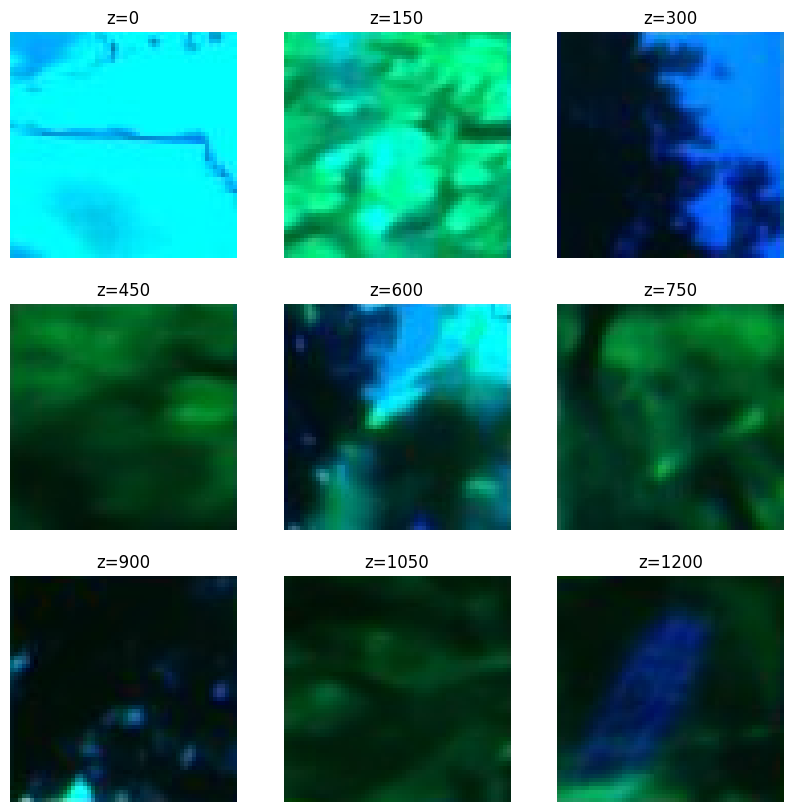

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axs.flat):
    frame = i * 150
    ax.set(xticks=[], yticks=[], title=f"z={frame}")
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')

## Skeleton

In [9]:
skel_dir = os.path.join(data_root, 'swc')
swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.swc')]
print(len(swc_files))

161


In [10]:
example_cell = {
    'nuc_id': "720575940567697697",
    'seg_id': "720575940559143627",
}

In [11]:
try:
    sys.path.append("../dev")
    from skel_sync import sync_skeletons
    sync_skeletons([example_cell['seg_id']], skel_dir)
except ImportError:
    pass  # dev-only helper, not present outside this machine; swc-examples.zip should already cover this

In [12]:
import skeliner as sk

skel = sk.io.load_swc(os.path.join(skel_dir, f"{example_cell['seg_id']}.swc"))

# Plot

In [13]:
%%time
from style import set_rc_params

set_rc_params()

CPU times: total: 109 ms
Wall time: 114 ms


In [14]:
%%time
fig_dir = f'../figures/calcium_data'
os.makedirs(fig_dir, exist_ok=True)

CPU times: total: 0 ns
Wall time: 294 μs


## Retina outline

In [15]:
tif_folder = f'{image_root}/highres-images-2p'
em_fields_folder = f'{image_root}/em-fields'

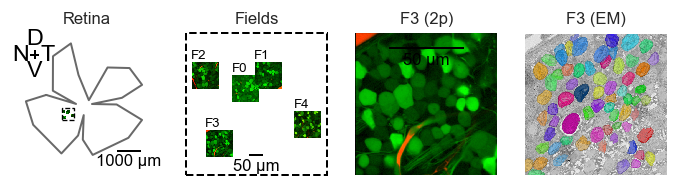

In [16]:
import plot
import tifffile
import matplotlib.image as mpimg

color_crop = 'k'

fig, axs = plt.subplot_mosaic(
    """
    ABCD
    """,
    figsize=(7, 2),
)

for name, ax in axs.items():
    ax.axis('off')
    if name not in ['H', 'G']:
        ax.set_aspect('equal')

xmin, xmax, ymin, ymax = plot.make_square_bounding_box(
    df_fields['field_temporal_nasal_pos_um'], df_fields['field_ventral_dorsal_pos_um'])

box_xlim = (xmin - 70, xmax + 70)
box_ylim = (ymin - 50, ymax + 90)

j = 0
ax = axs["A"]
ax.set_title('Retina')
ax.set(xlim=(-3000, 3000), ylim=(-3000, 3000))
ax.plot(np.append(df_outline['temporal_nasal_pos_um'].values[1:], df_outline['temporal_nasal_pos_um'].values[1]),
        np.append(df_outline['ventral_dorsal_pos_um'].values[1:], df_outline['ventral_dorsal_pos_um'].values[1]),
        c='dimgray', ls='-')

for i, row in df_fields.iterrows():
    field = int(row['field'][-1])
    extent = plot.get_extent(
        row[f'ch{j}_average'], row['pixel_size_um'], row['field_temporal_nasal_pos_um'],
        row['field_ventral_dorsal_pos_um'])
    im = tifffile.imread(os.path.join(tif_folder, f'GCL{field}.tif'))
    ax.imshow(im, extent=extent, interpolation='none')

plot.add_rect(ax, box_xlim, box_ylim, color_crop, linewidth=0.8)
plot.plot_retina_orientation(ax=ax, tdist=50, x0=-2200, y0=2100, size=400)
plot.plot_scale_bar(ax=ax, x0=1800, y0=-2000, size=1000, tdist=70)

ax = axs["B"]
ax.set_title('Fields')
for i, frow in df_fields.iterrows():
    field = int(frow['field'][-1])
    extent = plot.get_extent(frow[f'ch{j}_average'], frow['pixel_size_um'], frow['field_temporal_nasal_pos_um'],
                        frow['field_ventral_dorsal_pos_um'])
    im = tifffile.imread(os.path.join(tif_folder, f'GCL{field}.tif'))
    ax.imshow(im, extent=extent, interpolation='none')

    ax.text(frow['field_temporal_nasal_pos_um'] - 50, frow['field_ventral_dorsal_pos_um'] + 50,
            "F" + str(field), c='k', va='bottom', ha='left')

ax.set(xlim=box_xlim, ylim=box_ylim)
plot.add_rect(ax, box_xlim, box_ylim, color_crop)
plot.plot_scale_bar(ax=ax, x0=np.mean(box_xlim), y0=box_ylim[0] + 70, size=50, tdist=10)

field = 3
frow = df_fields[df_fields.field == f'GCL{field}'].iloc[0]

ax = axs["C"]
ax.set_title(f'F{field} (2p)')
extent = plot.get_extent(frow[f'ch{j}_average'], frow['pixel_size_um'], frow['field_temporal_nasal_pos_um'],
                    frow['field_ventral_dorsal_pos_um'])
im = tifffile.imread(os.path.join(tif_folder, f'GCL{field}.tif'))
ax.imshow(im, extent=extent, interpolation='none')
plot.plot_scale_bar(ax=ax, x0=float(np.mean(extent[:2])), y0=float(extent[2] + 0.9 * np.diff(extent[2:])[0]), size=50, tdist=3)

ax = axs["D"]
ax.set_title(f'F{field} (EM)')
im = mpimg.imread(os.path.join(em_fields_folder, f'{field}_v2.png'))
ax.imshow(im, interpolation='none')

plt.savefig(os.path.join(fig_dir, 'field-projections.svg'))

## Example cell - Skeleton

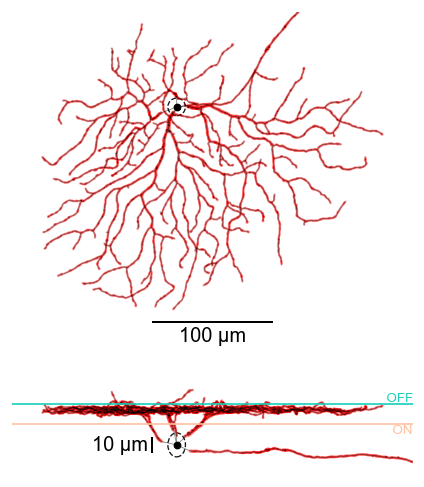

In [17]:
from skeleton import rotate_skel


skel_rot = rotate_skel(skel, rotation_deg=150)

xmax, ymax, zmax = np.max(skel_rot.nodes[skel_rot.ntype == 3], axis=0)
xmin, ymin, zmin = np.min(skel_rot.nodes[skel_rot.ntype == 3], axis=0)

xlim = (xmin - 10, xmax + 10)
ylim = (ymin - 25, ymax + 25)
zlim = (zmin - 20, zmax + 5)

fig, axs = plt.subplots(2, 1, figsize=(4, 5), height_ratios=(5, 1))

ax = axs[0]
sk.plot.projection(skel_rot, ax=ax, xlim=ylim, ylim=xlim, plane='yx', draw_cylinders=False)
plot.plot_scale_bar(ax=ax, x0=np.mean(ylim), y0=xlim[0], size=100, text=True, unit='µm', tdist=4, fontsize=12)

ax = axs[1]
sk.plot.projection(skel_rot, ax=ax, xlim=ylim, ylim=zlim, plane='yz')
plot.plot_sac_lines(ax, ylim)
ax.set_aspect('auto', 'box')
plot.plot_scale_bar(ax=ax, x0=skel_rot.soma.center[1] - 20, y0=skel_rot.soma.center[2],
               size=10, text=True, unit='µm', tdist=-50, fontsize=12, orientation='v')

for ax in axs:
    ax.axis('off')

plt.savefig(os.path.join(fig_dir, 'example-skeleton-projections.svg'))

## Example cell - Responses

In [18]:
row = df[df['Latest NucID'] == example_cell['nuc_id']].iloc[0]
row

Latest NucID                                        720575940567697697
Index                                                             D275
Nuc Coords                                           45282, 35996, 561
Nuc SupervoxID                                       78254854023339175
Soma Coords                                          45282, 35996, 661
                                           ...                        
prob_class                                                    0.938901
probs_per_cluster    [0.0018517031605307908, 0.0017731730417752712,...
qfilt                                                             True
2p-Field                                                          GCL3
2p-ROI                                                              52
Name: 275, Length: 142, dtype: object

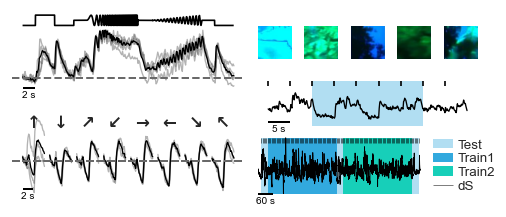

In [19]:
c_test = "#b1def2"
c_train1 = "#32a9de"
c_train2 = "#17cfb9"

scalebar_fs = 6

fig, axs = plt.subplot_mosaic(
    """
    AEFGHI
    ACCCCC
    .CCCCC
    BCCCCC
    BDDDDD
    """,
    figsize=(5, 2),
    width_ratios=(7, 1, 1, 1, 1, 1),
    height_ratios=(1, 0.2, 0.2, 0.2, 1),
)

ax = axs['A']
plot.plot_chirp(ax, row=row, stimulus_ms=chirp_stimulus, lw=0.8)
ax.axis('off')
plot.plot_scale_bar(ax=ax, x0=1, y0=-0.2, size=2, text=True, unit='s', tdist=0.05, fontsize=scalebar_fs)

ax = axs['B']
plot.plot_bar(ax, row=row, annotate_symbols=True, ventral_up=False, lw=0.8)
plot.plot_scale_bar(ax=ax, x0=1, y0=-0.7, size=2, text=True, unit='s', tdist=0.05, fontsize=scalebar_fs)
ax.axis('off')

ax = axs['D']
mc_trace = row.mc_pp_trace
mc_time = np.arange(mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0
mc_tt = row.mc_triggertimes
mc_tt = np.append(mc_tt, mc_tt[-1] + np.median(np.diff(mc_tt)))
mc_ylim = (mc_trace.min(), mc_trace.max())

ax.axis('off')
for test_i in [0, 59, 118]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color=c_test, lw=0, zorder=-10,
                    label='Test' if test_i == 0 else '_')

ax.fill_between(x=[mc_tt[5], mc_tt[5 + 54]], y1=mc_ylim[0], y2=mc_ylim[1], color=c_train1, lw=0, label='Train1', zorder=-10)
ax.fill_between(x=[mc_tt[59 + 5], mc_tt[59 + 54 + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color=c_train2, lw=0,
                label='Train2', zorder=-10)

ax.plot(mc_time, mc_trace, c='k', lw=0.5)
ax.vlines(mc_tt, ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k', linestyles='-', lw=0.3,
          label='dS')

ax.legend(bbox_to_anchor=(0.8, 0.5), loc='center left', borderaxespad=0., frameon=False, handlelength=1.5, )
plot.plot_scale_bar(ax=ax, x0=30, y0=mc_ylim[0] + 0, size=60, text=True, unit='s',
                    tdist=1, fontsize=scalebar_fs)
ax.set_xlim(mc_time[0], mc_time[-1] + (mc_time[-1] - mc_time[0]) * 0.35)

ax = axs['C']
tlim_test2 = (mc_tt[59] - mc_tt[59 + 5])
ilim = (mc_time >= mc_tt[59] - 10) & (mc_time <= mc_tt[59 + 5] + 10)
ax.axis('off')
ax.plot(mc_time[ilim], mc_trace[ilim], c='k', lw=0.8)
for test_i in [59]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color=c_test, lw=0, zorder=-10,
                    label='Test' if test_i == 0 else '_')

ax.vlines(mc_tt[59 - 2:59 + 5 + 2], ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k',
          linestyles='-', lw=1)
plot.plot_scale_bar(ax=ax, x0=mc_tt[57] + 2.5, y0=mc_ylim[0] + 2, size=5, text=True, unit='s', tdist=1, fontsize=scalebar_fs)

for i in range(5):
    seq = 59 + i
    frame = seq * 30 * 5
    ax = axs[['E', 'F', 'G', 'H', 'I'][i]]
    ax.set(xticks=[], yticks=[])
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')
plt.savefig(os.path.join(fig_dir, 'example-RGC-responses.svg'))

In [20]:
from watermark import watermark
print(watermark())

Last updated: 2026-09-16T18:28:19.922344+02:00

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.13.0

Compiler    : MSC v.1943 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
CPU cores   : 8
Architecture: 64bit

